<a href="https://colab.research.google.com/github/MariaMuu/Creatine-Simulation-Analysis/blob/main/Cleaned_creatine_synthetic_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Important libraries

In [188]:
import pandas as pd
import numpy as np

In [189]:
df = pd.read_csv('/content/synthetic_creatine_study.csv')

### Initial exploration

In [190]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 833 entries, 0 to 832
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             788 non-null    object 
 1   age              792 non-null    float64
 2   sex              791 non-null    object 
 3   dose_g           791 non-null    float64
 4   sleep_score      792 non-null    float64
 5   mood_score       792 non-null    float64
 6   cognition_score  791 non-null    float64
dtypes: float64(5), object(2)
memory usage: 45.7+ KB


In [191]:
# show the first 50 rows

df.head(50)

,name,age,sex,dose_g,sleep_score,mood_score,cognition_score
0,Vasileios Karagiannis,28.0,male,14.285214,7.505528,67.122028,115.977027
1,Christos Georgiou,39.0,male,13.078266,5.341051,59.524379,106.545224
2,Christos Georgiou,36.0,male,5.446547,6.274310,59.882594,92.989228
3,Alexandra Dimopoulos,30.0,NaN,25.468375,5.943014,65.241407,113.689930
4,Vasiliki Konstantinidis,50.0,female,10.258739,6.839209,66.517821,96.246922
5,Anastasios Ioannidis,64.0,male,16.955851,6.828478,63.171471,103.036039
6,Evangelia Ioannidis,41.0,female,29.753709,6.557338,79.521047,121.204846
7,Dimitra Dimopoulos,40.0,female,15.806020,6.258968,75.295466,100.670915
8,Anastasios Dimopoulos,44.0,male,6.461365,7.090825,56.661634,103.350907
9,NaN,33.0,female,13.658044,7.357442,66.392850,105.381263


In [192]:
# show the last 50 rows

df.tail(50)

,name,age,sex,dose_g,sleep_score,mood_score,cognition_score
783,Anastasia Papadopoulos,63.0,female,10.722365,NaN,50.200749,106.551812
784,NaN,999.0,male,250.000000,60.000000,800.000000,900.000000
785,Nikolaos Nikolaou,46.0,male,19.926173,6.111526,69.926723,105.129372
786,Sofia Ioannidis,38.0,female,NaN,7.460265,49.553044,108.609084
787,Georgios Konstantinidis,43.0,male,23.983608,8.534840,77.479403,107.566692
788,Nikolaos Vasileiou,52.0,male,15.965180,7.506706,72.016468,103.512421
789,Vasileios Adamidis,45.0,male,13.063199,6.191843,54.661589,103.200420
790,NaN,5.0,male,100.000000,25.000000,300.000000,400.000000
791,Anna Konstantinidis,42.0,female,24.002352,5.507466,68.297961,113.325326
792,Spyridon Adamidis,NaN,male,6.999135,6.962667,53.219451,101.771289


###Removing names for GDPR reasons, not necessary to do data masking or pseudoanymization

In [193]:
df_new = df.drop(['name'], axis = 1 )
df_new

,age,sex,dose_g,sleep_score,mood_score,cognition_score
0,28.0,male,14.285214,7.505528,67.122028,115.977027
1,39.0,male,13.078266,5.341051,59.524379,106.545224
2,36.0,male,5.446547,6.274310,59.882594,92.989228
3,30.0,NaN,25.468375,5.943014,65.241407,113.689930
4,50.0,female,10.258739,6.839209,66.517821,96.246922
...,...,...,...,...,...,...
828,27.0,male,8.479951,7.024969,70.177010,99.979841
829,24.0,female,13.430678,5.353932,72.435327,118.864323
830,43.0,female,9.422179,7.512902,60.233227,102.974477
831,47.0,female,NaN,7.571448,67.469846,113.014602


### Rename 'dose_g' column to 'creatine_dose_g'

In [194]:
df_new.rename(columns = {'dose_g': 'creatine_dose_g'}, inplace = True)
df_new

,age,sex,creatine_dose_g,sleep_score,mood_score,cognition_score
0,28.0,male,14.285214,7.505528,67.122028,115.977027
1,39.0,male,13.078266,5.341051,59.524379,106.545224
2,36.0,male,5.446547,6.274310,59.882594,92.989228
3,30.0,NaN,25.468375,5.943014,65.241407,113.689930
4,50.0,female,10.258739,6.839209,66.517821,96.246922
...,...,...,...,...,...,...
828,27.0,male,8.479951,7.024969,70.177010,99.979841
829,24.0,female,13.430678,5.353932,72.435327,118.864323
830,43.0,female,9.422179,7.512902,60.233227,102.974477
831,47.0,female,NaN,7.571448,67.469846,113.014602


### Round creatine values

In [195]:
df_new['creatine_dose_g'] = df_new['creatine_dose_g'].round()
df_new

,age,sex,creatine_dose_g,sleep_score,mood_score,cognition_score
0,28.0,male,14.0,7.505528,67.122028,115.977027
1,39.0,male,13.0,5.341051,59.524379,106.545224
2,36.0,male,5.0,6.274310,59.882594,92.989228
3,30.0,NaN,25.0,5.943014,65.241407,113.689930
4,50.0,female,10.0,6.839209,66.517821,96.246922
...,...,...,...,...,...,...
828,27.0,male,8.0,7.024969,70.177010,99.979841
829,24.0,female,13.0,5.353932,72.435327,118.864323
830,43.0,female,9.0,7.512902,60.233227,102.974477
831,47.0,female,NaN,7.571448,67.469846,113.014602


### Check missing values

In [196]:
df_new.isnull().sum()

,0
age,41
sex,42
creatine_dose_g,42
sleep_score,41
mood_score,41
cognition_score,42


### Fill missing values in each numerical column with its median

In [197]:
# Identify numerical columns to fill missing values
numerical_cols = df_new.select_dtypes(include=np.number).columns

# Fill missing values in each numerical column with its median
for col in numerical_cols:
    median_val = df_new[col].median()
    df_new[col] = df_new[col].fillna(median_val)
    print(f"Filled missing values in '{col}' with median: {median_val}")

print("\nMissing values after imputation:")
print(df_new.isnull().sum())

Filled missing values in 'age' with median: 42.0
Filled missing values in 'creatine_dose_g' with median: 18.0
Filled missing values in 'sleep_score' with median: 6.745303853092812
Filled missing values in 'mood_score' with median: 65.78961950771189
Filled missing values in 'cognition_score' with median: 106.82297051685596

Missing values after imputation:
age                 0
sex                42
creatine_dose_g     0
sleep_score         0
mood_score          0
cognition_score     0
dtype: int64


### Check different unique values in the 'sex' column

In [198]:
df_new['sex'].unique()

array(['male', nan, 'female', 'm', 'MALE', 'M', 'F', 'FEMALE', 'f'],
      dtype=object)

In [199]:
# Convert all entries to lowercase AND strip any leading/trailing whitespace
df_new['sex'] = df_new['sex'].str.lower().str.strip()

# Define a mapping for variations using the .replace() method
# .replace() will only replace the keys specified, leaving other values (like 'male', 'female') as is.
sex_replace_map = {
    'm': 'male',
    'f': 'female'
}
df_new['sex'] = df_new['sex'].replace(sex_replace_map)

# Fill any remaining NaN values with 'unknown'
df_new['sex'] = df_new['sex'].fillna('unknown')

print("Unique values in 'sex' column after standardization and imputation:")
print(df_new['sex'].unique())

print("\nMissing values after 'sex' column processing:")
print(df_new.isnull().sum())

Unique values in 'sex' column after standardization and imputation:
['male' 'unknown' 'female']

Missing values after 'sex' column processing:
age                0
sex                0
creatine_dose_g    0
sleep_score        0
mood_score         0
cognition_score    0
dtype: int64


In [200]:
df_new.describe()

,age,creatine_dose_g,sleep_score,mood_score,cognition_score
count,833.000000,833.000000,833.000000,833.000000,833.000000
mean,42.214886,17.758703,6.865238,67.093039,107.894674
std,35.768495,11.065066,2.243649,30.311050,30.660575
min,5.000000,-10.000000,-5.000000,-150.000000,-100.000000
25%,30.000000,11.000000,6.109864,59.040103,103.060078
50%,42.000000,18.000000,6.745304,65.789620,106.822971
75%,52.000000,23.000000,7.428798,71.954489,110.514058
max,999.000000,250.000000,60.000000,800.000000,900.000000


### Outlier Detection using Box Plots

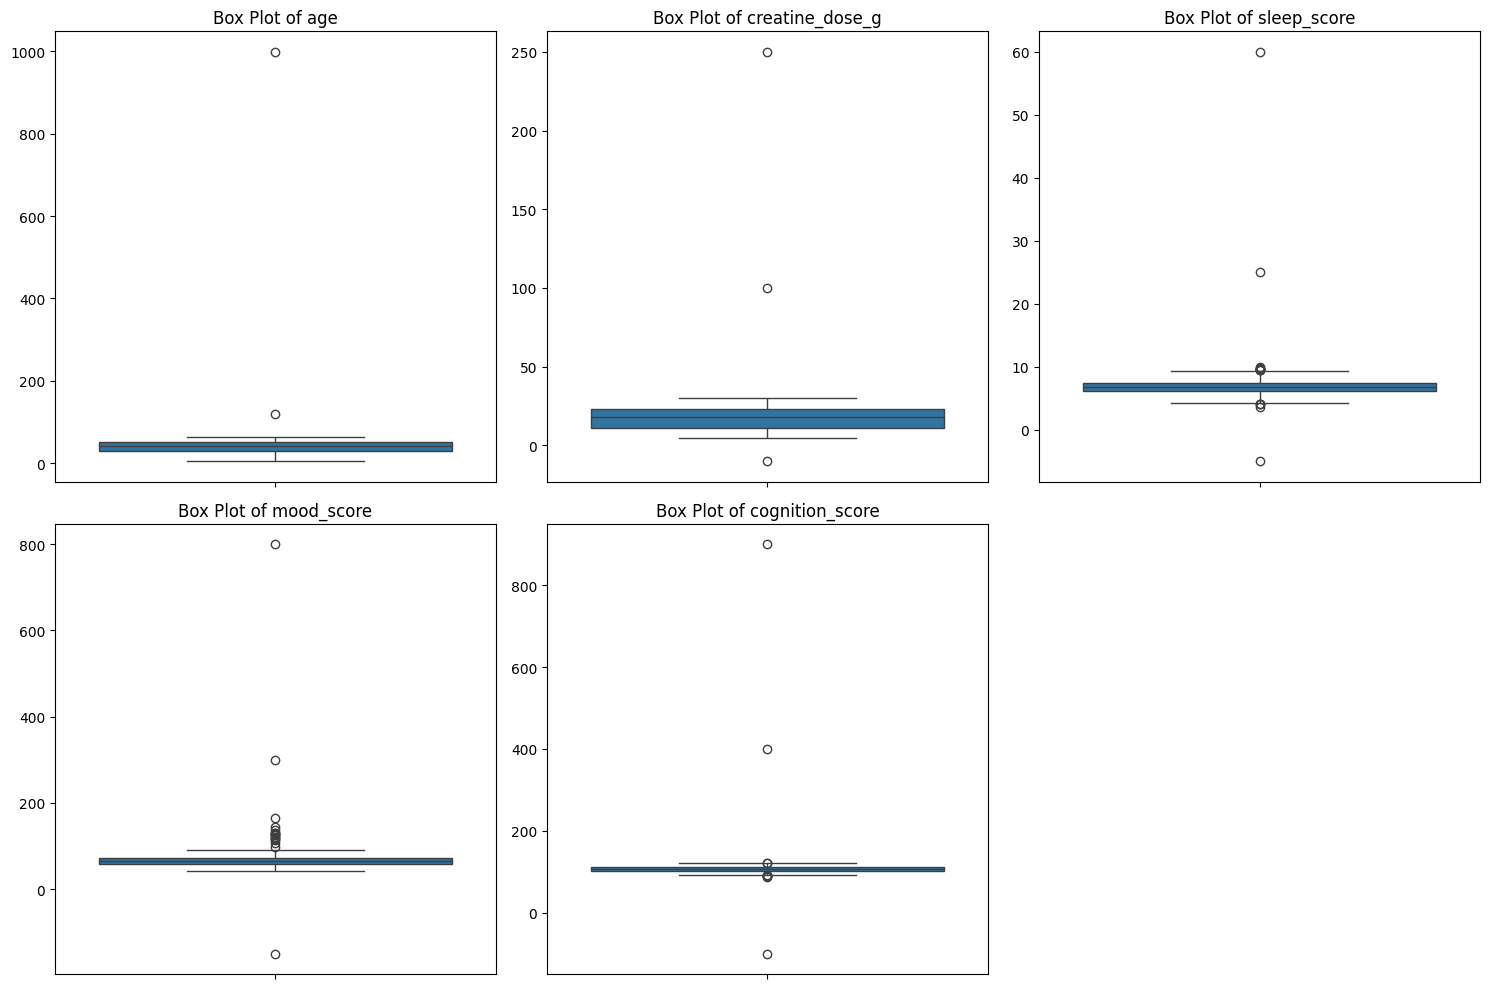

In [201]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for outlier detection
numerical_cols = df_new.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1)  # Adjust subplot grid as needed
    sns.boxplot(y=df_new[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel('')
plt.tight_layout()
plt.show()

### Outlier Detection using IQR Method

In [202]:
numeric_cols = df_new.select_dtypes(include=np.number)

outlier_counts = {}

for col in numeric_cols:
    Q1 = df_new[col].quantile(0.25)
    Q3 = df_new[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_counts[col] = ((df_new[col] < lower) | (df_new[col] > upper)).sum()

print(outlier_counts)

{'age': np.int64(2), 'creatine_dose_g': np.int64(3), 'sleep_score': np.int64(15), 'mood_score': np.int64(17), 'cognition_score': np.int64(10)}


In [203]:
df_cleaned_outliers = df_new.copy() # Create a copy to store the changes

# Get all numerical columns
numerical_cols = df_cleaned_outliers.select_dtypes(include=np.number).columns

# Loop through each numerical column to find and fill outliers with its median
for col in numerical_cols:
    Q1 = df_cleaned_outliers[col].quantile(0.25)
    Q3 = df_cleaned_outliers[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    median_val = df_cleaned_outliers[col].median()

    # Identify outliers using the IQR method
    outliers_iqr = (df_cleaned_outliers[col] < lower_bound) | (df_cleaned_outliers[col] > upper_bound)

    # Count identified outliers
    num_outliers = outliers_iqr.sum()

    if num_outliers > 0:
        # Replace values below the lower bound or above the upper bound with the median
        df_cleaned_outliers.loc[outliers_iqr, col] = median_val
        print(f"Filled {num_outliers} outliers in '{col}' with median: {median_val}")
    else:
        print(f"No outliers found or filled in '{col}'.")

print("\n---")

print("Descriptive statistics AFTER outlier imputation:\n")
print(df_cleaned_outliers[numerical_cols].describe())

# Update df_new with the cleaned DataFrame
df_new = df_cleaned_outliers.copy()

Filled 2 outliers in 'age' with median: 42.0
Filled 3 outliers in 'creatine_dose_g' with median: 18.0
Filled 15 outliers in 'sleep_score' with median: 6.745303853092812
Filled 17 outliers in 'mood_score' with median: 65.78961950771189
Filled 10 outliers in 'cognition_score' with median: 106.82297051685596

---
Descriptive statistics AFTER outlier imputation:

              age  creatine_dose_g  sleep_score  mood_score  cognition_score
count  833.000000       833.000000   833.000000  833.000000       833.000000
mean    40.972389        17.415366     6.779597   65.181638       106.903273
std     13.049203         6.959557     0.977750    9.246040         5.290276
min      5.000000         5.000000     4.169936   40.718408        92.688674
25%     30.000000        11.000000     6.125109   59.053618       103.281395
50%     42.000000        18.000000     6.745304   65.789620       106.822971
75%     52.000000        23.000000     7.396089   71.302130       110.395342
max     64.000000     

### Replace ages < 18 with median

In [204]:
# 1. Calculate the median from the valid adult population (18+)
df_new_median_age = df_new[df_new['age'] >= 18]['age'].median()

# 2. Identify the rows where age is logically too low (e.g., age 5)
age_to_replace = (df_new['age'] < 18)

# 3. Replace those specific values with the overall median
df_new.loc[age_to_replace, 'age'] = df_new_median_age

print(f"Median age used for replacement: {df_new_median_age}")
print(f"The DataFrame has been updated. New minimum age: {df_new['age'].min()}")
display(df_new.describe())


Median age used for replacement: 42.0
The DataFrame has been updated. New minimum age: 18.0


,age,creatine_dose_g,sleep_score,mood_score,cognition_score
count,833.000000,833.000000,833.000000,833.000000,833.000000
mean,41.016807,17.415366,6.779597,65.181638,106.903273
std,12.989445,6.959557,0.977750,9.246040,5.290276
min,18.000000,5.000000,4.169936,40.718408,92.688674
25%,30.000000,11.000000,6.125109,59.053618,103.281395
50%,42.000000,18.000000,6.745304,65.789620,106.822971
75%,52.000000,23.000000,7.396089,71.302130,110.395342
max,64.000000,30.000000,9.340552,91.210374,121.691095


In [205]:
df_new

,age,sex,creatine_dose_g,sleep_score,mood_score,cognition_score
0,28.0,male,14.0,7.505528,67.122028,115.977027
1,39.0,male,13.0,5.341051,59.524379,106.545224
2,36.0,male,5.0,6.274310,59.882594,92.989228
3,30.0,unknown,25.0,5.943014,65.241407,113.689930
4,50.0,female,10.0,6.839209,66.517821,96.246922
...,...,...,...,...,...,...
828,27.0,male,8.0,7.024969,70.177010,99.979841
829,24.0,female,13.0,5.353932,72.435327,118.864323
830,43.0,female,9.0,7.512902,60.233227,102.974477
831,47.0,female,18.0,7.571448,67.469846,113.014602


In [206]:
df_new.to_csv("cleaned_synthetic_creatine_study.csv", index=False)